# Quasiharmonic Approximations (QHA) for $\ce{MgO}$ with [MatterSim](https://github.com/microsoft/mattersim)

## Import Necessary Packages

In [1]:
import numpy as np
from pylab import *

## Custom Define Functions

In [2]:
def set_fig_properties(ax_list, panel_color_str='black', line_width=2):
    tl = 4
    tw = 2
    tlm = 2

    for ax in ax_list:
        ax.tick_params(which='major', length=tl, width=tw)
        ax.tick_params(which='minor', length=tlm, width=tw)
        ax.tick_params(which='both', axis='both', direction='in',
                       right=True, top=True)
        ax.spines['bottom'].set_color(panel_color_str)
        ax.spines['top'].set_color(panel_color_str)
        ax.spines['left'].set_color(panel_color_str)
        ax.spines['right'].set_color(panel_color_str)

        ax.spines['bottom'].set_linewidth(line_width)
        ax.spines['top'].set_linewidth(line_width)
        ax.spines['left'].set_linewidth(line_width)
        ax.spines['right'].set_linewidth(line_width)

        for t in ax.xaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.yaxis.get_ticklines(): t.set_color(panel_color_str)
        for t in ax.xaxis.get_ticklines(): t.set_linewidth(line_width)
        for t in ax.yaxis.get_ticklines(): t.set_linewidth(line_width)

## Denote Latex Font for Plots

In [3]:
# Denote plot default format
aw = 2
fs = 12
font = {'size': fs}
matplotlib.rc('font', **font)
matplotlib.rc('axes', linewidth=aw)

# Configure Matplotlib to use a LaTeX-like style without LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

## Illustrate $\alpha$ vs. T up till Room temperature
- Experimental $\alpha$ are adopted from: [handbook on physical properties of semiconductors](https://link.springer.com/book/10.1007/1-4020-7821-8)

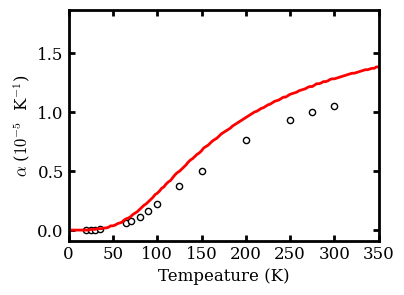

In [4]:
# Initalize temperature array and low in thermal expansion coefficients
temperature = np.linspace(0, 900, 361)
coefficients_of_thermal_expansions = np.load('kaldo_runs/alpha_T.npy', allow_pickle=True)
lattice = np.load('kaldo_runs/L_T.npy', allow_pickle=True)
free_energies = np.load('kaldo_runs/F_T.npy', allow_pickle=True)


# Tabluate experimental data
tempature_exp = np.array([20, 25, 30, 35, 65, 
                          70, 80, 90, 100, 125, 
                         150, 200, 250, 275, 300,
                         400, 500, 600, 700, 800, 900])

alpha_exp = np.array([0.012, 0.022, 0.039, 0.065, 0.59,
                     0.76, 1.15, 1.65, 2.2, 3.7, 5.0, 
                     7.6, 9.3, 10.0, 10.5, 11.8, 
                      12.7, 13.3, 14.0, 14.5, 14.8])/10

fig = figure(figsize=(4,3))
set_fig_properties([gca()])
scatter(tempature_exp, alpha_exp, edgecolor='k', facecolor='w', marker='o', s=20, zorder=1, label='Experimental CTE by G. K. White and O. L. Anderson.')
plot(temperature, 1e5 * coefficients_of_thermal_expansions, 'r-', lw=2, label=r'$\kappa$ALDo QHA using MatterSim')
#legend(loc='upper center', fontsize=7)
gca().set_xticks(np.arange(0, 500, 50))
xlabel('Tempeature (K)')
ylabel(r'$\alpha$ ($10^{-5}$  K$^{-1}$)')
xlim([0, 350])
show()

# Plot thermal expansion ($\alpha$), lattice constants $\&$ free energies

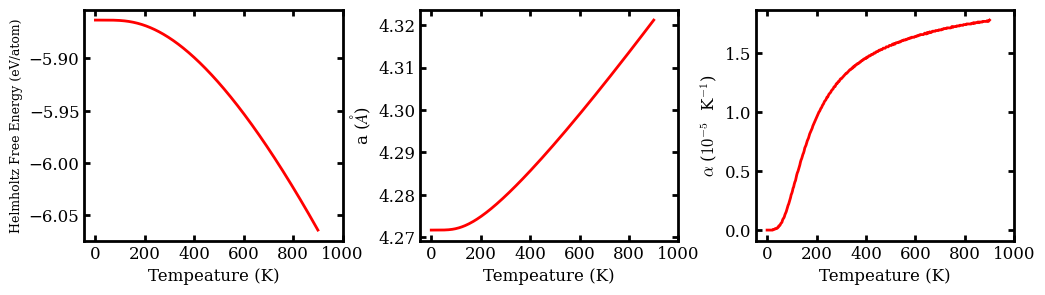

In [5]:
fig = figure(figsize=(12,3))

subplot(1,3,1)
set_fig_properties([gca()])
plot(temperature, free_energies/1000, 'r-', lw=2)

gca().set_xticks(np.arange(0, 1200, 200))
xlabel('Tempeature (K)')
ylabel(r"Helmholtz Free Energy (eV/atom)", fontsize=9)


subplot(1,3,2)
set_fig_properties([gca()])
plot(temperature, lattice, 'r-', lw=2)

gca().set_xticks(np.arange(0, 1200, 200))
xlabel('Tempeature (K)')
ylabel(r'a ($\AA$)')

subplot(1,3,3)
set_fig_properties([gca()])
plot(temperature, 1e5 * coefficients_of_thermal_expansions, 'r-', lw=2)
gca().set_xticks(np.arange(0, 1200, 200))
xlabel('Tempeature (K)')
ylabel(r'$\alpha$ ($10^{-5}$  K$^{-1}$)')
subplots_adjust(hspace=0, wspace=0.3)
show()